# Project 6 — Notebook 19: Infrastructure Stress Analysis

**Scope:** NCR (Region 3) reactive fault tickets — same 36,907-ticket base as Projects 1–5.

**Questions answered:**
1. Which NE types carry the most infrastructure stress (high ticket volume × high breach rate × high MTTR)?
2. Where are repeat failures concentrated — same site, same NE type, ticket after ticket?
3. How does site complexity (NE-type diversity) correlate with SLA performance?
4. Which zones are most exposed to infrastructure stress and why?

**Outputs:** `ne_stress_profile.csv`, `repeat_failure_sites.csv`, `site_complexity_stress.csv`, `infra_zone_summary.csv`

---

## 1. Setup

In [1]:
import sys, os
os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from src.projects.project6_infra import (
    build_ne_stress_profile,
    compute_site_complexity,
    identify_repeat_failures,
    zone_infra_summary,
)
from config import ZONE_PALETTE, DEFAULT_DPI, DEFAULT_FIGSIZE

FIGURE_DIR = 'reports/figures/project6_ncr'
os.makedirs(FIGURE_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': DEFAULT_DPI,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

STRESS_CMAP = LinearSegmentedColormap.from_list('stress', ['#d4f1c0', '#f9d342', '#e05c5c'])

## 2. Load Cleaned Data

In [2]:
df = pd.read_csv('output/cleaned_fault_ticket.csv')

# NCR only
df = df[df['Region'] == 'Region 3'].copy()
print(f"NCR reactive tickets: {len(df):,}")
print(f"Zones: {sorted(df['ZONE'].dropna().unique())}")
print(f"NE types: {df['NEType'].nunique()} unique")
print(f"Sites: {df['SiteName'].nunique()} unique")

NCR reactive tickets: 38,319
Zones: ['Unknown', 'ZONE 1', 'ZONE 2', 'ZONE 3', 'ZONE 4', 'ZONE 5', 'ZONE 6']
NE types: 40 unique
Sites: 4803 unique


## 2. NE Type Stress Profile

Stress Index = `breach_rate × log1p(ticket_count) × (MTTR / NCR_mean_MTTR)`  
Combines frequency, non-compliance severity, and recovery difficulty into one ranking signal.

In [3]:
ne_stress = build_ne_stress_profile(df)

print("Top 15 NE types by Stress Index:")
display(ne_stress[['Rank','NEType','NE_Category','Ticket_Count','Avg_MTTR',
                    'SLA_Rate','Breach_Rate','Stress_Index','High_Impact']]
        .head(15)
        .style.format({
            'Avg_MTTR': '{:.1f}h',
            'SLA_Rate': '{:.1%}',
            'Breach_Rate': '{:.1%}',
            'Stress_Index': '{:.3f}',
        })
        .background_gradient(subset='Stress_Index', cmap=STRESS_CMAP)
)
ne_stress.to_csv('output/ne_stress_profile.csv', index=False)

Top 15 NE types by Stress Index:


,Rank,NEType,NE_Category,Ticket_Count,Avg_MTTR,SLA_Rate,Breach_Rate,Stress_Index,High_Impact
0,1,vCGW,Core Network,1,3027.5h,0.0%,100.0%,13.948,True
1,2,HYBRID_A,Access,50,866.5h,66.0%,34.0%,7.699,False
2,3,CELL,Access,934,270.0h,65.6%,34.4%,4.220,False
3,4,MSS,Core Network,196,196.6h,44.9%,55.1%,3.803,True
4,5,CGNAT,Core Network,761,281.2h,86.3%,13.7%,1.695,True
5,6,BNG,IP/Network Infra,271,311.5h,89.3%,10.7%,1.242,True
6,7,ROUTER,IP/Network Infra,63,113.7h,63.5%,36.5%,1.147,True
7,8,ENODEB,Access,8787,69.4h,79.4%,20.6%,0.864,False
8,9,PDH,Transport,73,100.5h,71.2%,28.8%,0.827,False
9,10,AG,Core Network,1278,91.4h,81.9%,18.1%,0.785,True


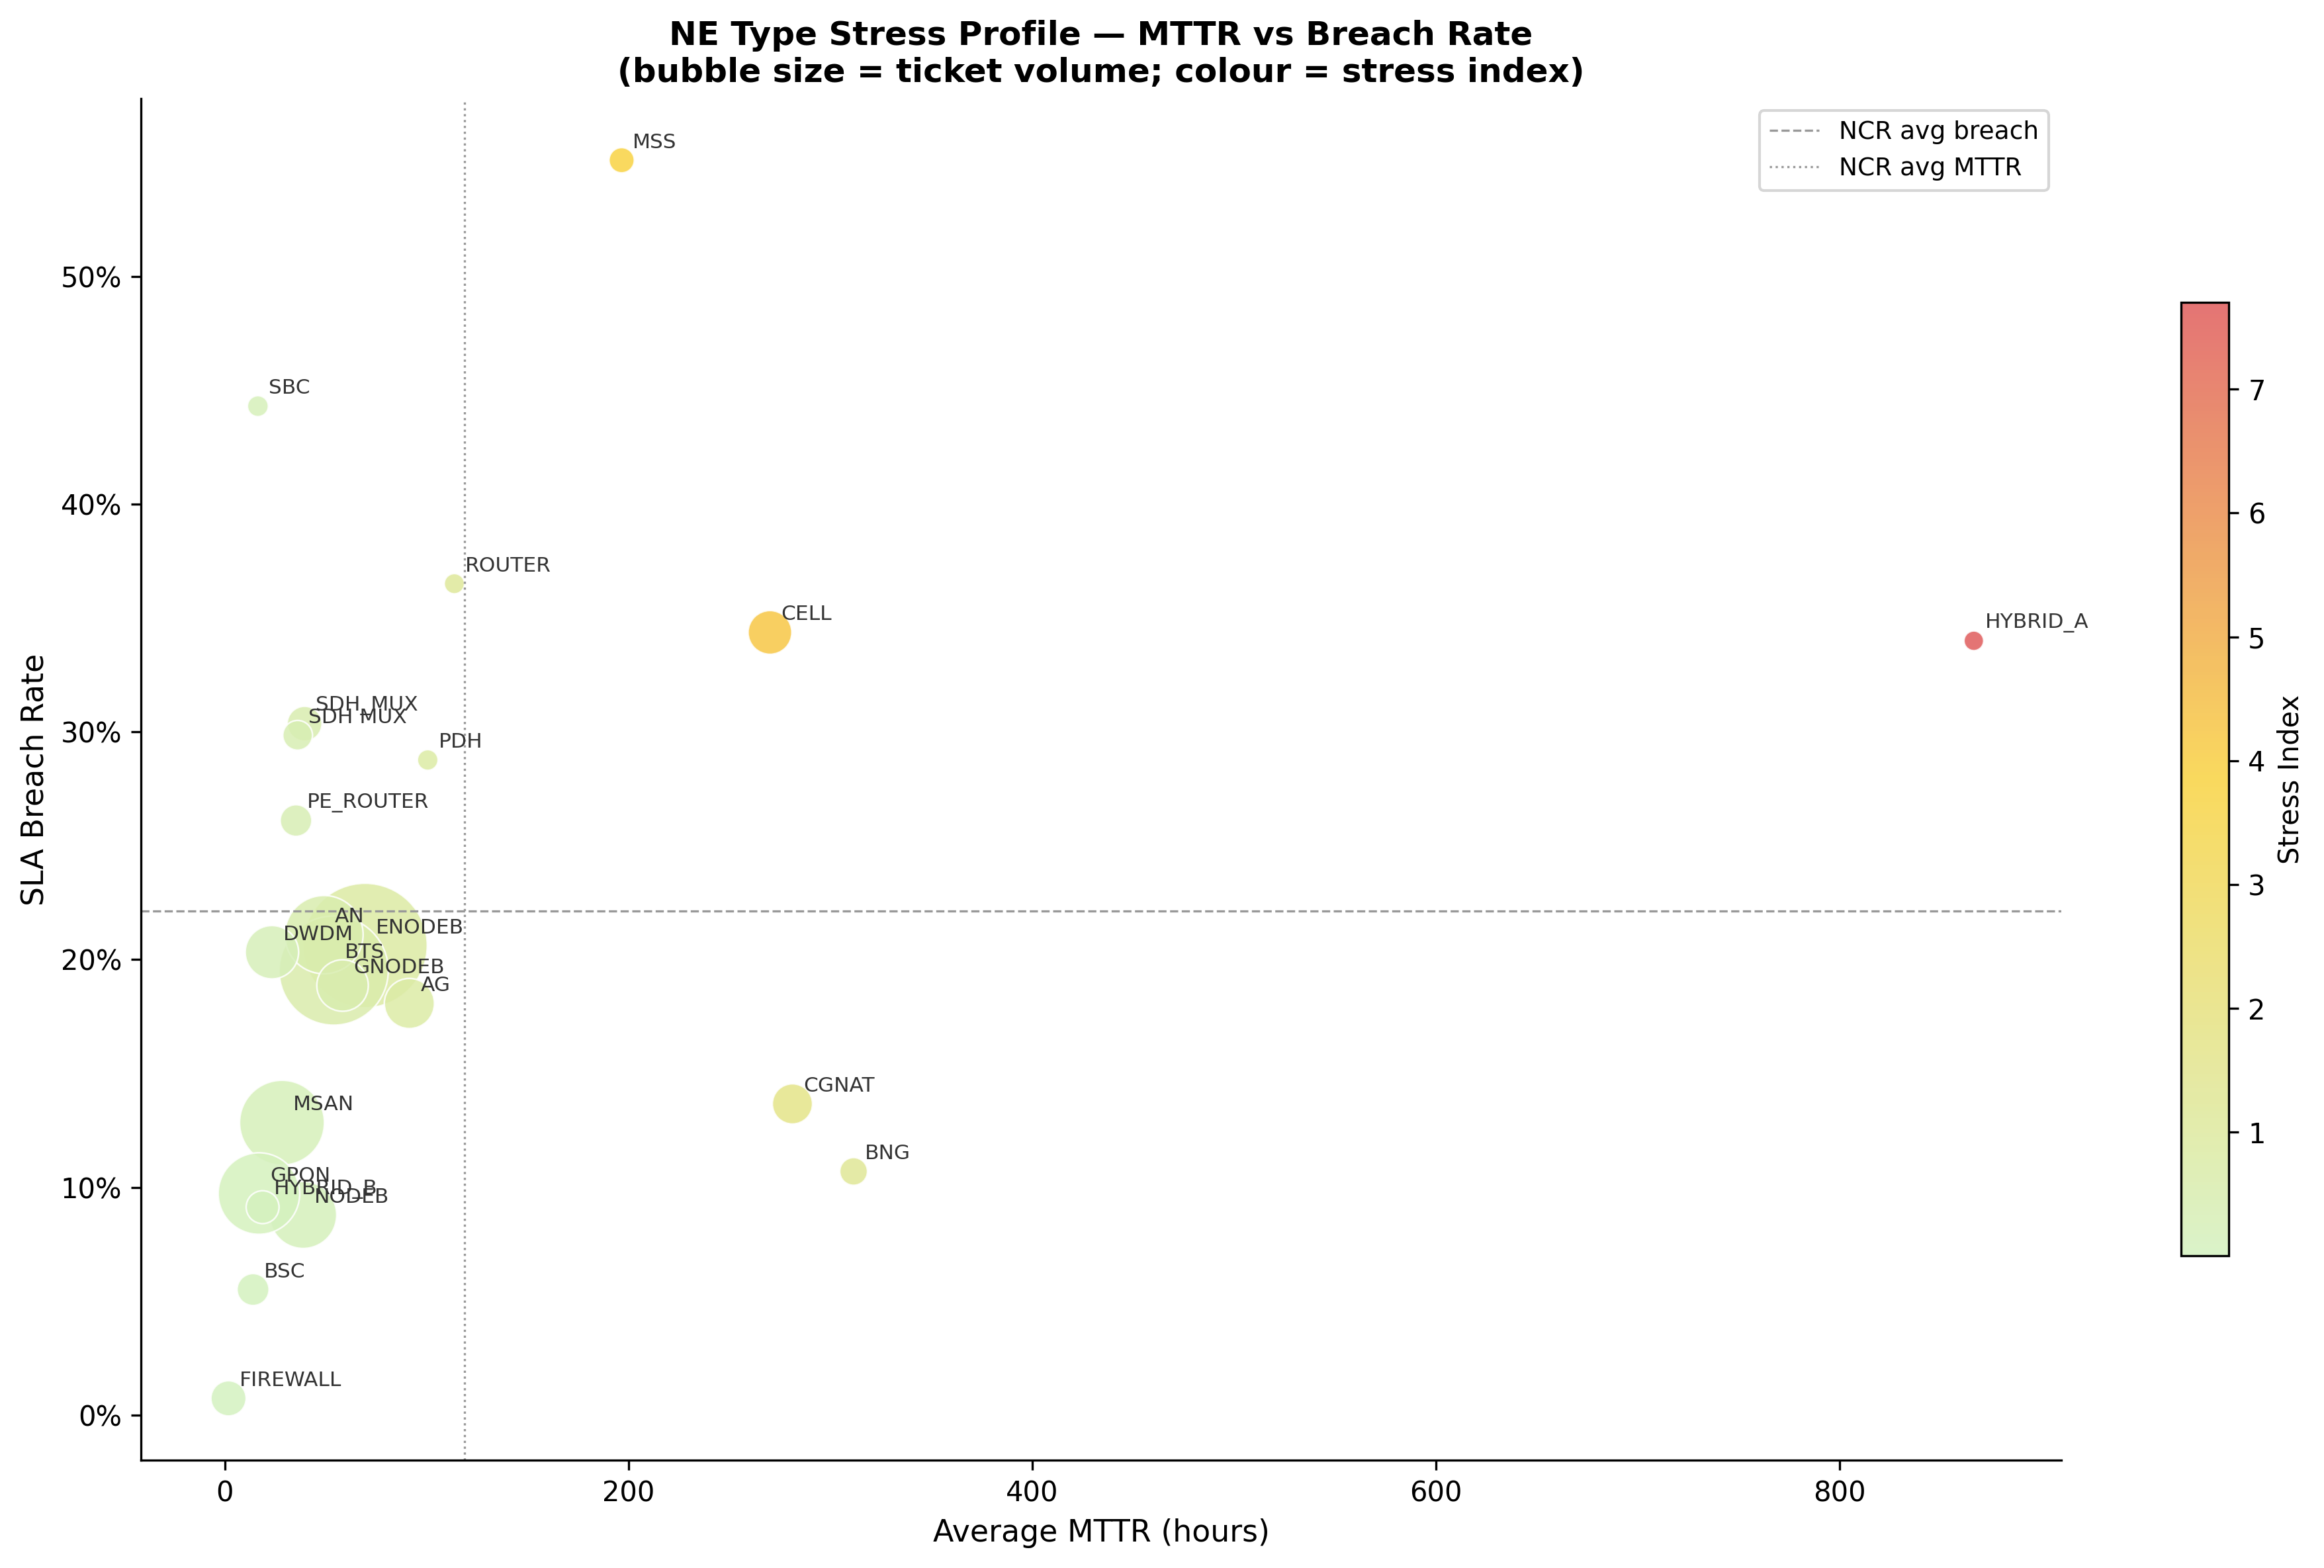

Saved fig01_ne_stress_bubble.png


In [4]:
# ── Figure 1: NE Stress Bubble Chart ─────────────────────────────────────────
# x=MTTR, y=Breach_Rate, size=Ticket_Count, colour=Stress_Index
plot_df = ne_stress[ne_stress['Ticket_Count'] >= 50].copy()   # filter noise

fig, ax = plt.subplots(figsize=(13, 8))

scatter = ax.scatter(
    plot_df['Avg_MTTR'],
    plot_df['Breach_Rate'],
    s = plot_df['Ticket_Count'] / plot_df['Ticket_Count'].max() * 2000 + 40,
    c = plot_df['Stress_Index'],
    cmap = STRESS_CMAP,
    alpha = 0.85,
    edgecolors = 'white',
    linewidths = 0.6,
)

for _, row in plot_df.iterrows():
    ax.annotate(
        row['NEType'],
        (row['Avg_MTTR'], row['Breach_Rate']),
        fontsize=7.5, ha='left', va='bottom',
        xytext=(4, 3), textcoords='offset points',
        color='#333333',
    )

plt.colorbar(scatter, ax=ax, label='Stress Index', shrink=0.7)

ax.set_xlabel('Average MTTR (hours)', fontsize=11)
ax.set_ylabel('SLA Breach Rate', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(plot_df['Breach_Rate'].mean(), color='#999', ls='--', lw=0.8, label='NCR avg breach')
ax.axvline(plot_df['Avg_MTTR'].mean(),   color='#999', ls=':',  lw=0.8, label='NCR avg MTTR')
ax.legend(fontsize=9)
ax.set_title('NE Type Stress Profile — MTTR vs Breach Rate\n(bubble size = ticket volume; colour = stress index)', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig01_ne_stress_bubble.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()
print("Saved fig01_ne_stress_bubble.png")

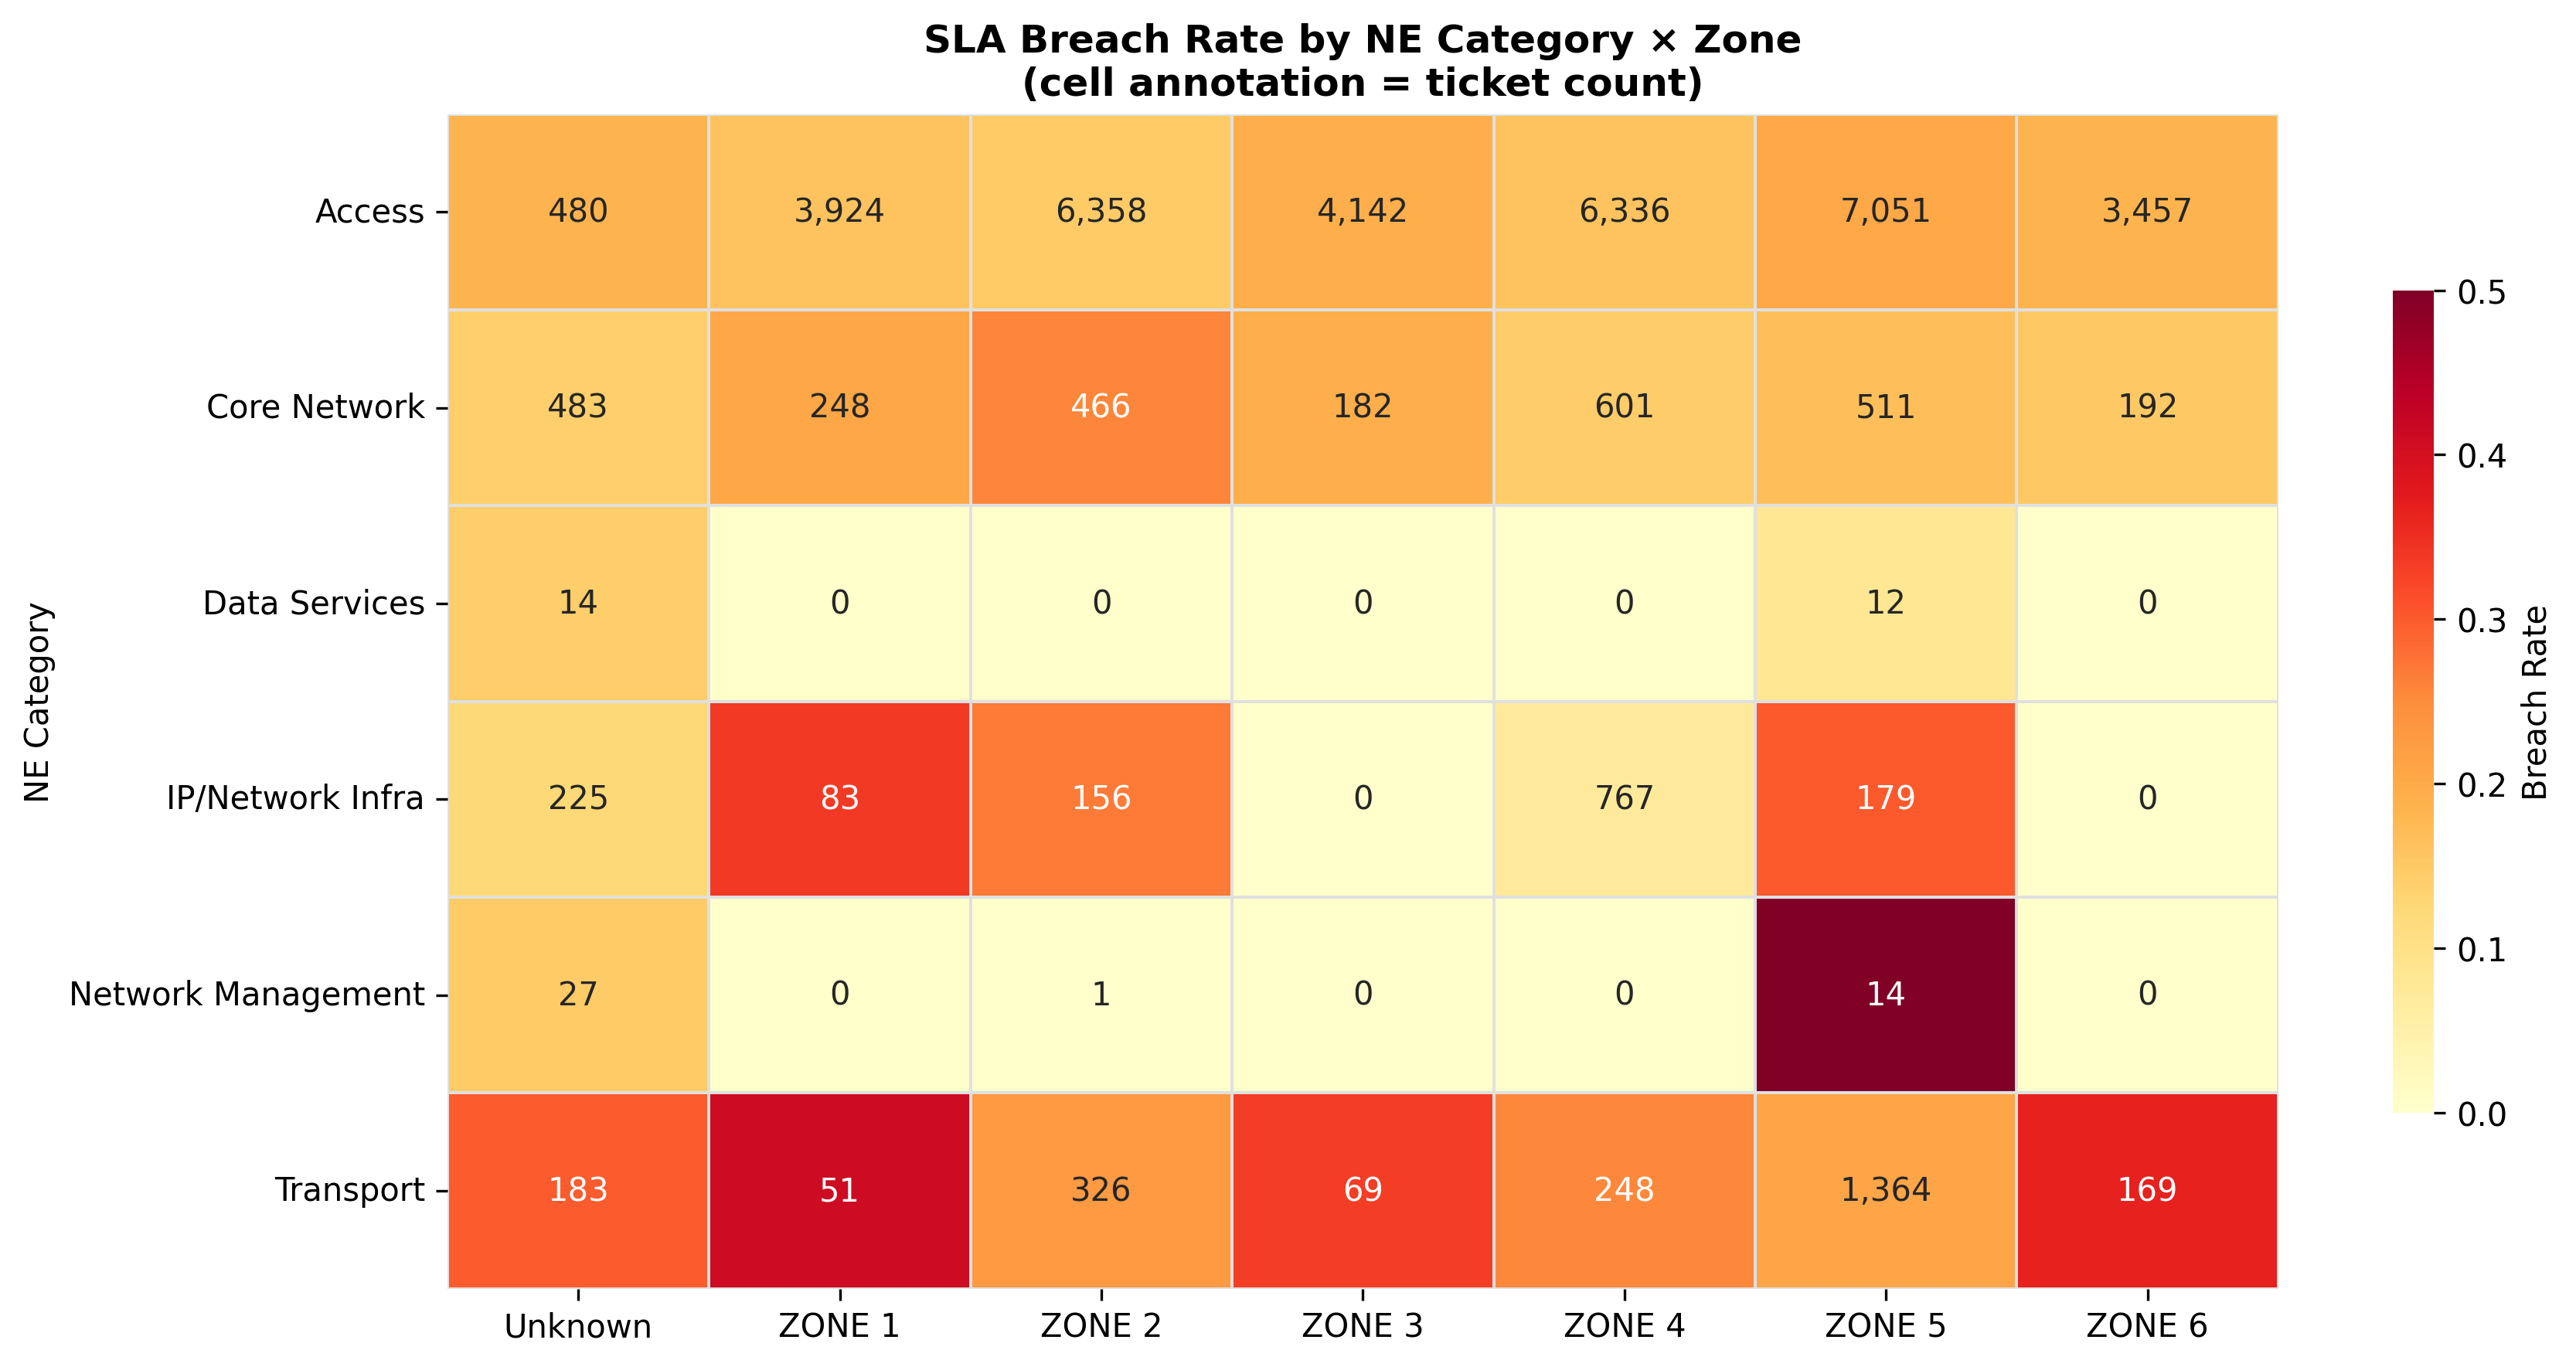

In [6]:
# ── Figure 2: NE Category stress heatmap (zone × NE category) ────────────────
cat_zone = df.groupby(['ZONE', 'NE_Category']).agg(
    Breach_Rate = ('SLA_Compliant', lambda x: 1 - x.mean()),
    Ticket_Count = ('OUTAGEDURATION', 'count'),
).reset_index()

# Pivot to heatmap
pivot = cat_zone.pivot(index='NE_Category', columns='ZONE', values='Breach_Rate').fillna(0)

# Annotation pivot (ticket count)
count_pivot = cat_zone.pivot(index='NE_Category', columns='ZONE', values='Ticket_Count').fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    pivot,
    ax=ax,
    cmap='YlOrRd',
    annot=count_pivot.map(lambda x: f'{int(x):,}'),
    fmt='',
    linewidths=0.5,
    linecolor='#e0e0e0',
    cbar_kws={'label': 'Breach Rate', 'shrink': 0.7},
    vmin=0, vmax=0.5,
)
ax.set_title('SLA Breach Rate by NE Category × Zone\n(cell annotation = ticket count)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('NE Category')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/19_ne_category_breach_heatmap.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

## 4. Repeat Failure Analysis

A repeat failure is defined as ≥ 3 tickets on the **same site × NE type** combination during the study window.  
This signals either chronic hardware degradation, an unresolved root cause, or inadequate PM coverage.

In [7]:
repeat = identify_repeat_failures(df, min_tickets=3)

print(f"Repeat failure site×NE combinations: {len(repeat):,}")
print(f"Total tickets in repeat combos: {repeat['Repeat_Ticket_Count'].sum():,}")
print(f"Share of NCR tickets: {repeat['Repeat_Ticket_Count'].sum() / len(df):.1%}")
print()
print("Top 20 by repeat ticket count:")
display(repeat.head(20)[['SiteName','NEType','NE_Category','ZONE','Repeat_Ticket_Count',
                          'Avg_MTTR','Breach_Rate']]
        .style.format({'Avg_MTTR': '{:.1f}h', 'Breach_Rate': '{:.1%}'})
        .background_gradient(subset='Repeat_Ticket_Count', cmap='Reds')
)
repeat.to_csv('output/repeat_failure_sites.csv', index=False)

Repeat failure site×NE combinations: 4,342
Total tickets in repeat combos: 29,419
Share of NCR tickets: 76.8%

Top 20 by repeat ticket count:


,SiteName,NEType,NE_Category,ZONE,Repeat_Ticket_Count,Avg_MTTR,Breach_Rate
0,Region3_MAKATI CITY_89796080,DWDM,Transport,ZONE 5,536,11.9h,17.0%
1,Region3_SAN JUAN CITY_b5b00bf5,FIREWALL,IP/Network Infra,ZONE 4,487,1.5h,0.4%
2,Region3_MAKATI CITY_e38bb3d3,DWDM,Transport,ZONE 5,463,5.6h,13.0%
3,Region3_SAN JUAN CITY_b5b00bf5,CGNAT,Core Network,ZONE 4,278,79.3h,14.4%
4,Region3_Unknown_ebc3e6c9,CGNAT,Core Network,Unknown,219,458.9h,14.6%
5,Region3_SAN JUAN CITY_b5b00bf5,BNG,IP/Network Infra,ZONE 4,177,340.0h,9.0%
6,Region3_MAKATI CITY_89796080,CGNAT,Core Network,ZONE 5,133,3.0h,3.0%
7,Region3_Unknown_Unknown,AG,Core Network,Unknown,133,38.2h,11.3%
8,Region3_MAKATI CITY_89796080,AG,Core Network,ZONE 5,107,79.5h,16.8%
9,Region3_QUEZON CITY_2c40fd71,MSS,Core Network,ZONE 2,102,186.8h,54.9%


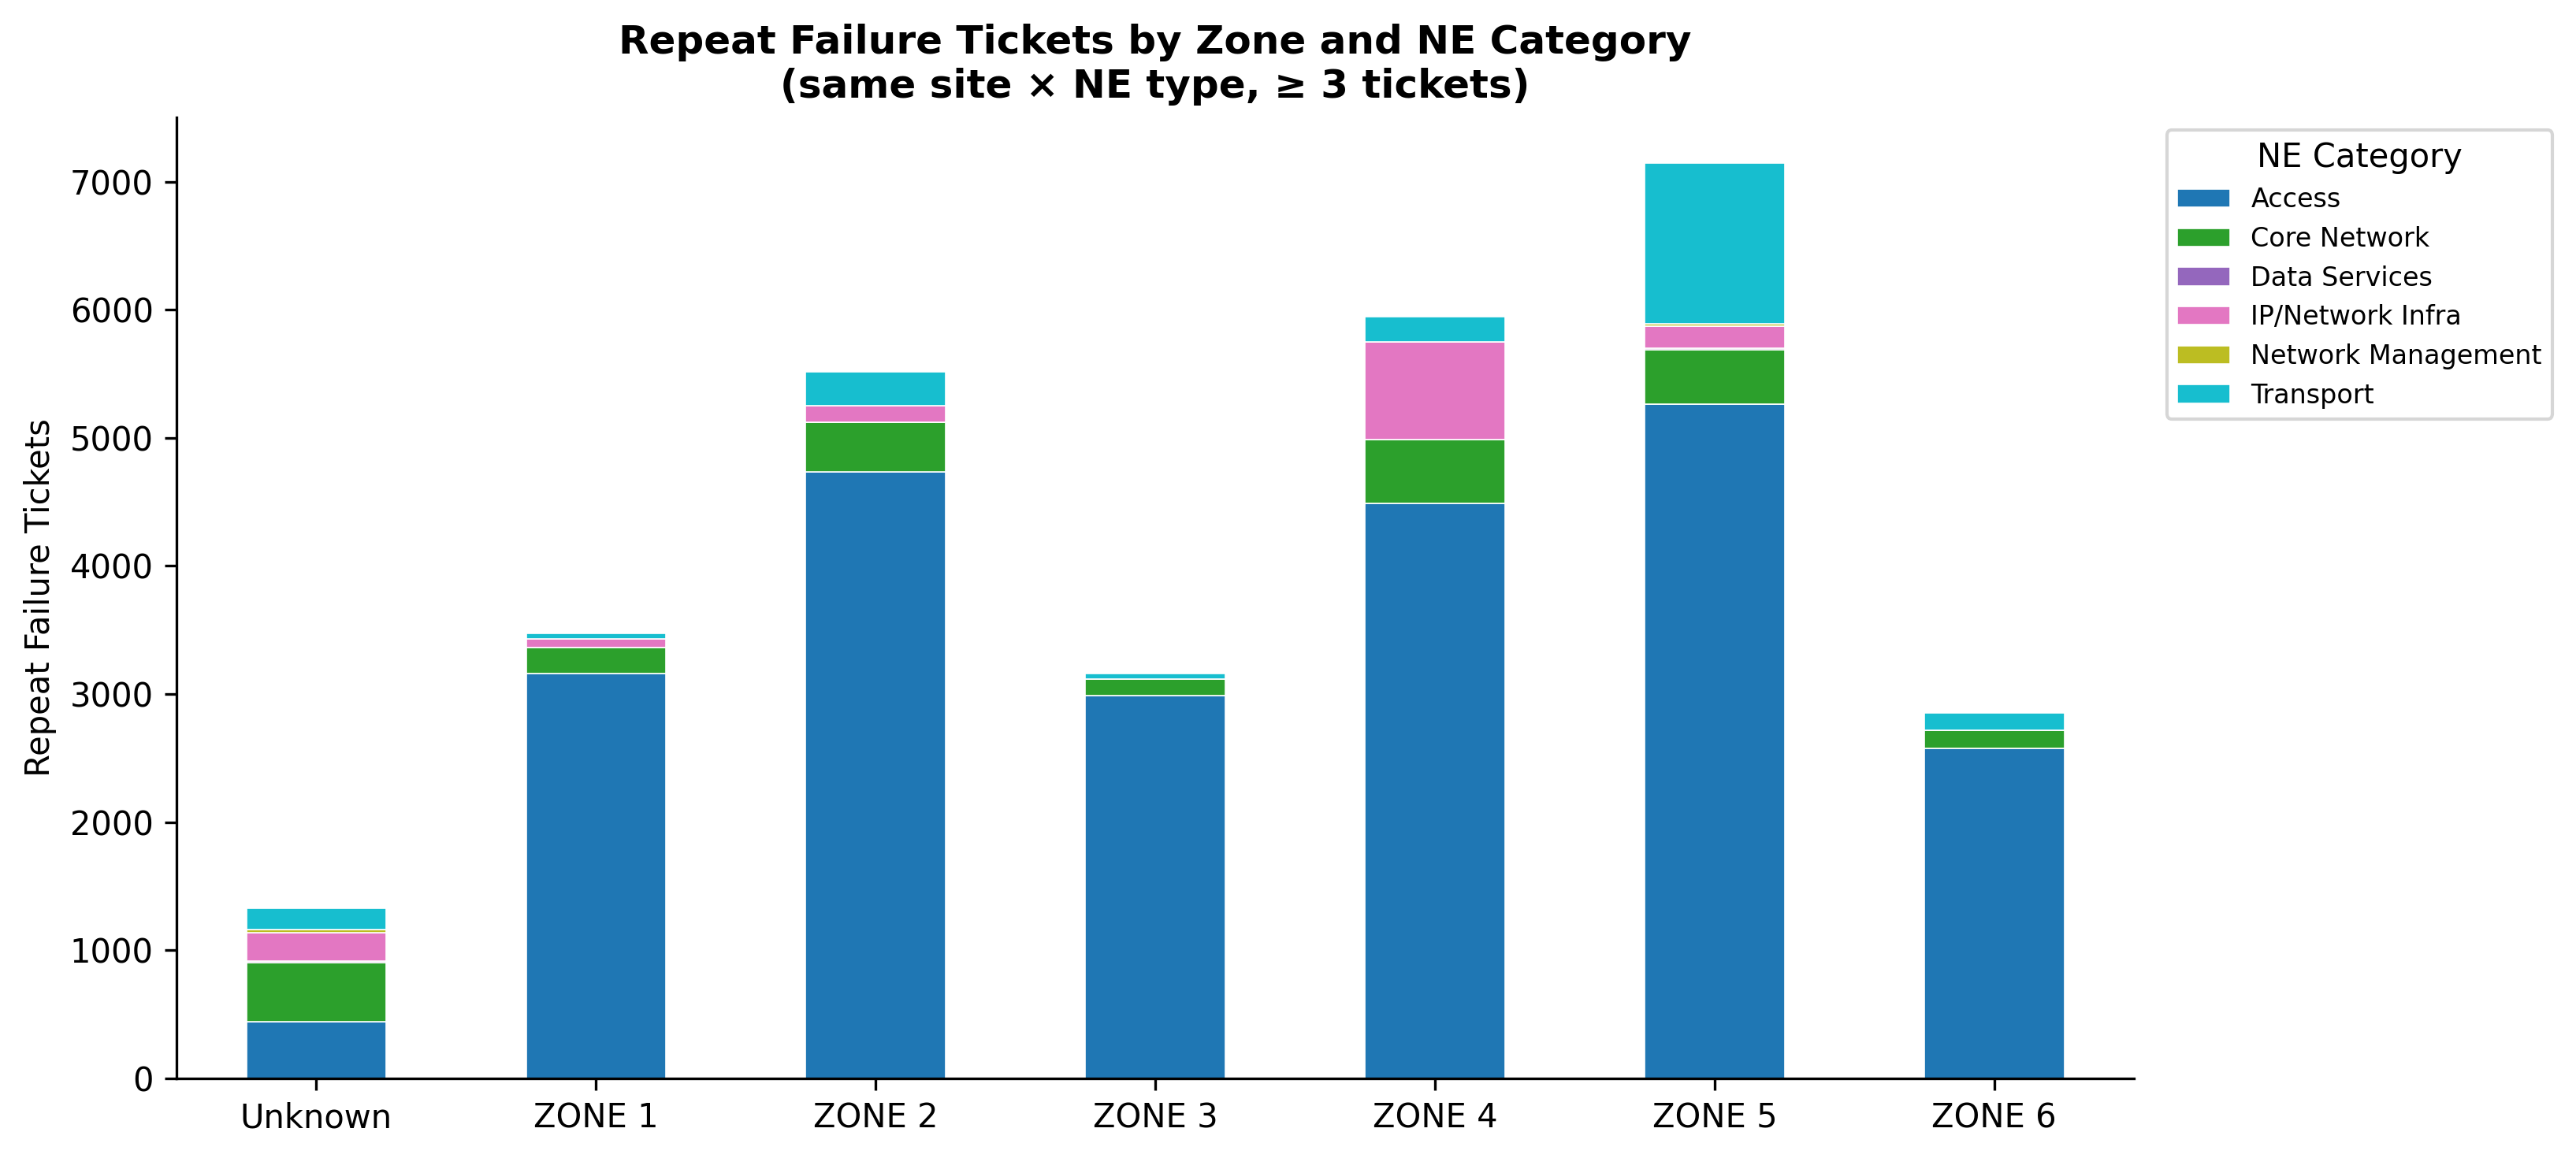

In [8]:
# ── Figure 3: Repeat failures by zone and NE category ─────────────────────────
if 'ZONE' in repeat.columns:
    zone_ne_repeat = repeat.groupby(['ZONE', 'NE_Category'])['Repeat_Ticket_Count'].sum().reset_index()
    pivot_r = zone_ne_repeat.pivot(index='NE_Category', columns='ZONE', values='Repeat_Ticket_Count').fillna(0)

    fig, ax = plt.subplots(figsize=(11, 5))
    pivot_r.T.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white', linewidth=0.4)
    ax.set_xlabel('')
    ax.set_ylabel('Repeat Failure Tickets')
    ax.set_title('Repeat Failure Tickets by Zone and NE Category\n(same site × NE type, ≥ 3 tickets)',
                 fontsize=12, fontweight='bold')
    ax.legend(title='NE Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/19_repeat_failures_zone_ne.png', dpi=DEFAULT_DPI, bbox_inches='tight')
    plt.show()

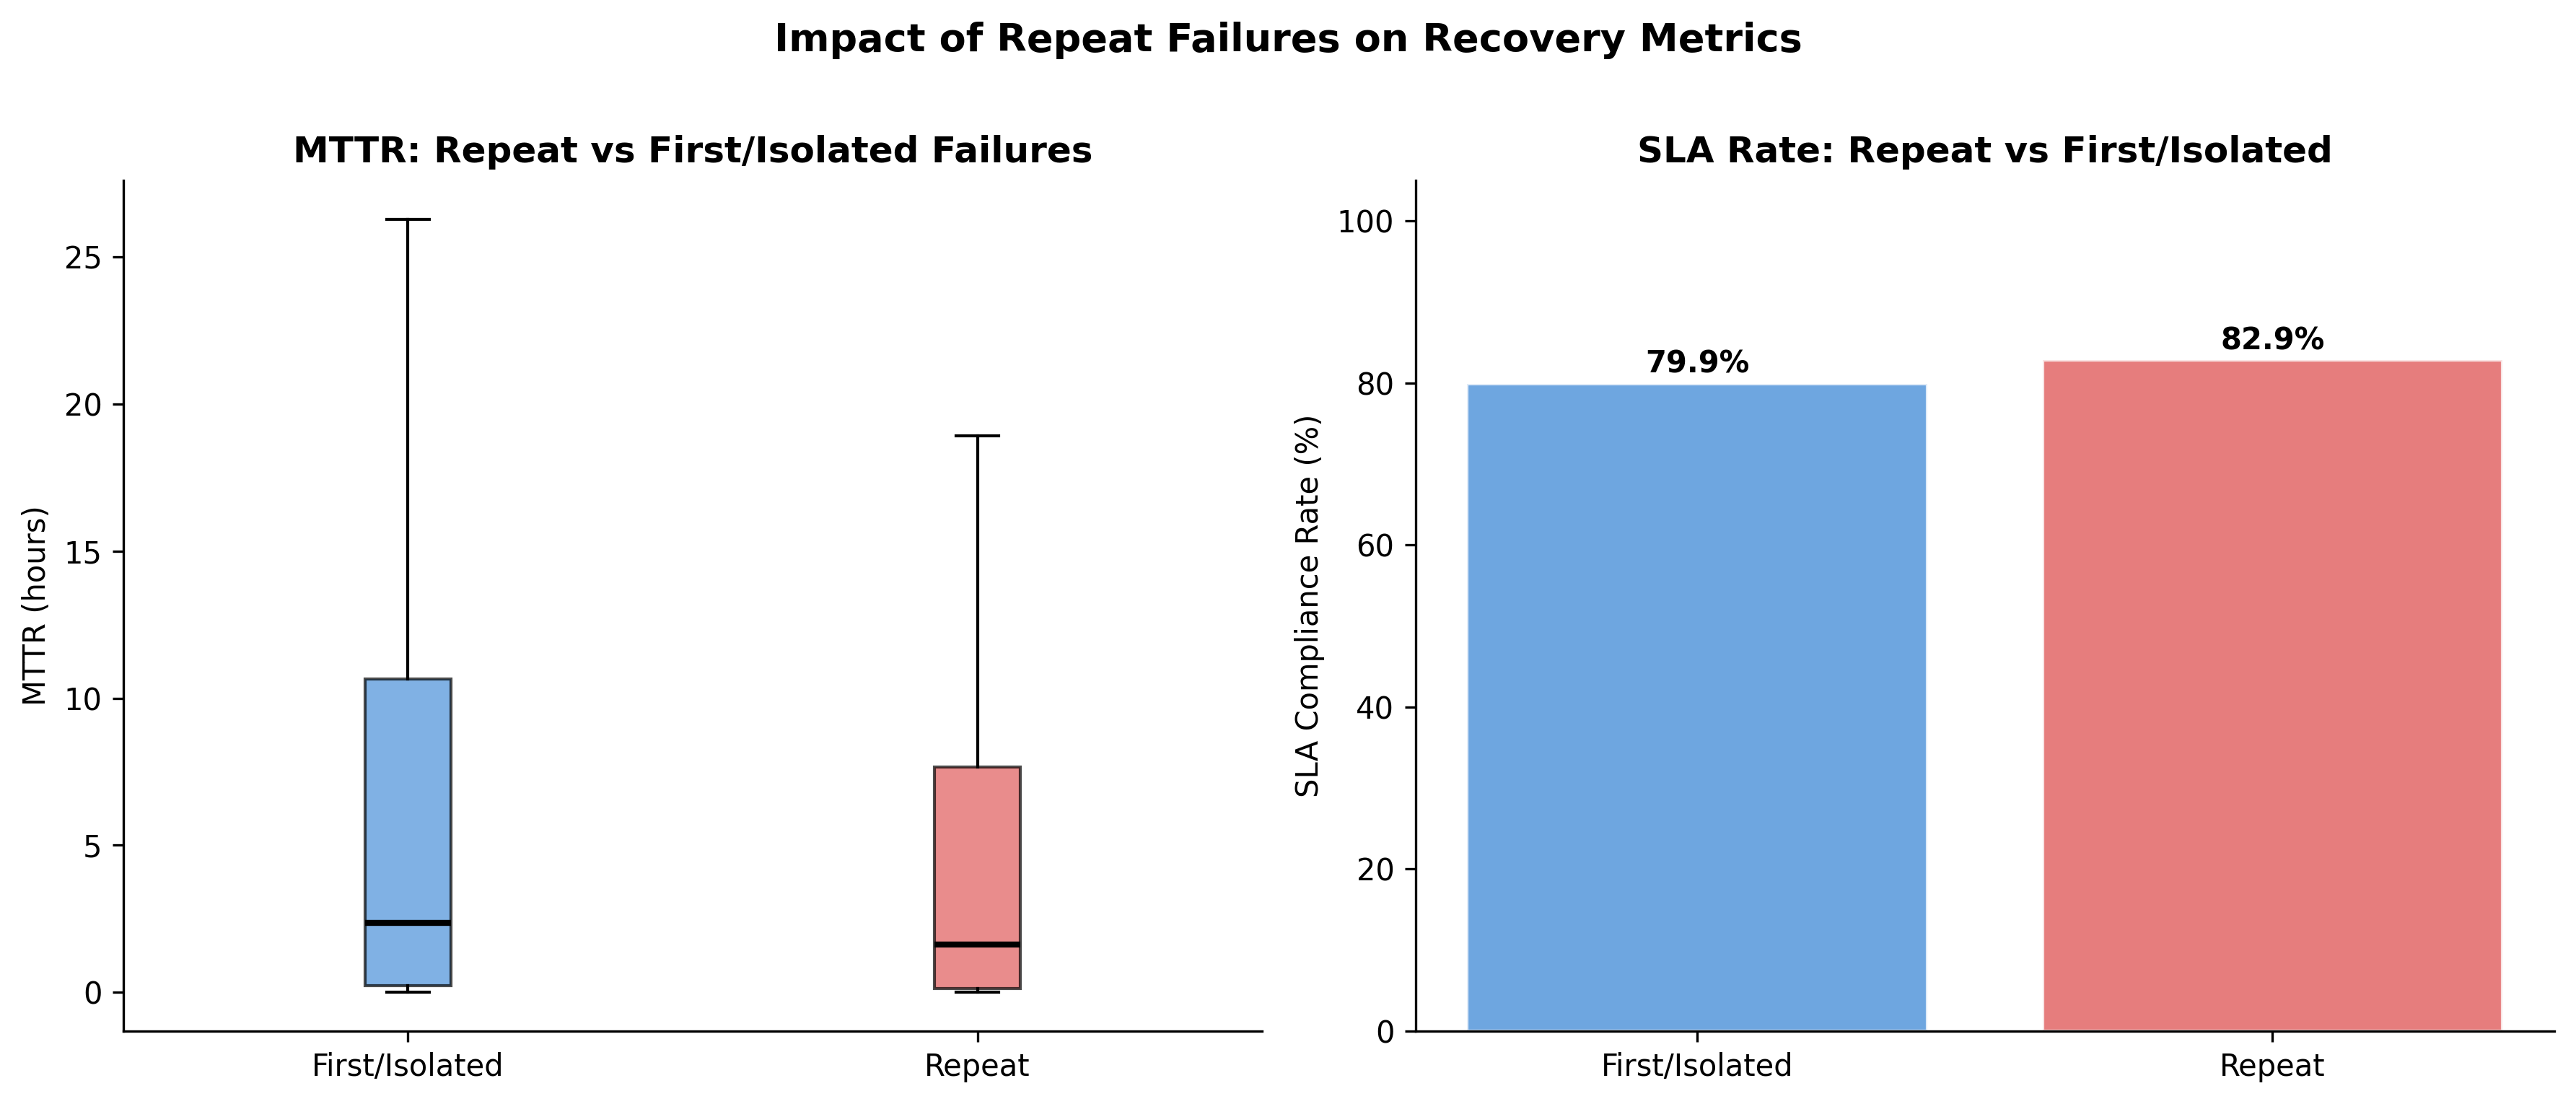


MTTR summary:
                  count  mean     std  min  25%  50%   75%      max
Is_Repeat                                                          
First/Isolated   8900.0  77.6  1131.5  0.0  0.2  2.4  10.7  96448.8
Repeat          29419.0  56.5   432.2  0.0  0.1  1.6   7.6  17760.7

SLA rates:
Is_Repeat
First/Isolated    79.9%
Repeat            82.9%
Name: SLA_Compliant, dtype: str


In [9]:
# ── Figure 4: Repeat vs non-repeat MTTR comparison ────────────────────────────
repeat_site_ne = set(zip(repeat['SiteName'], repeat['NEType'])) if 'SiteName' in repeat.columns else set()

df['Is_Repeat'] = df.apply(
    lambda r: 'Repeat' if (r.get('SiteName',''), r.get('NEType','')) in repeat_site_ne else 'First/Isolated',
    axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MTTR box plot
ax = axes[0]
groups = [df[df['Is_Repeat'] == g]['OUTAGEDURATION'].dropna() for g in ['First/Isolated', 'Repeat']]
bp = ax.boxplot(groups, tick_labels=['First/Isolated', 'Repeat'], patch_artist=True,
                medianprops={'color':'black','linewidth':2},
                showfliers=False)
colors = ['#4a90d9', '#e05c5c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('MTTR (hours)')
ax.set_title('MTTR: Repeat vs First/Isolated Failures', fontweight='bold')

# SLA bar chart
ax2 = axes[1]
sla_comp = df.groupby('Is_Repeat')['SLA_Compliant'].mean()
bars = ax2.bar(sla_comp.index, sla_comp.values * 100,
               color=['#4a90d9', '#e05c5c'], alpha=0.8, edgecolor='white')
for bar, val in zip(bars, sla_comp.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.set_ylabel('SLA Compliance Rate (%)')
ax2.set_ylim(0, 105)
ax2.set_title('SLA Rate: Repeat vs First/Isolated', fontweight='bold')

plt.suptitle('Impact of Repeat Failures on Recovery Metrics', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/19_repeat_vs_isolated_metrics.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

print("\nMTTR summary:")
print(df.groupby('Is_Repeat')['OUTAGEDURATION'].describe().round(1).to_string())
print("\nSLA rates:")
print(df.groupby('Is_Repeat')['SLA_Compliant'].mean().map('{:.1%}'.format))

## 5. Site Complexity vs Performance

Do sites with more NE types (higher complexity) suffer worse SLA?  
Project 5 established three complexity tiers (Low/Medium/High). Here we test the correlation rigorously.

In [10]:
site_cx = compute_site_complexity(df)

print(f"Total sites analysed: {len(site_cx):,}")
print()
print("Complexity tier distribution:")
tier_summary = site_cx.groupby('Complexity_Tier').agg(
    Sites         = ('SiteName', 'count'),
    Total_Tickets = ('Ticket_Count', 'sum'),
    Avg_MTTR      = ('Avg_MTTR', 'mean'),
    Avg_SLA_Rate  = ('SLA_Rate', 'mean'),
    Avg_Breach    = ('Breach_Rate', 'mean'),
    Core_IP_Sites = ('Has_Core_IP', 'sum'),
).round(3)
display(tier_summary.style.format({
    'Avg_MTTR': '{:.1f}h',
    'Avg_SLA_Rate': '{:.1%}',
    'Avg_Breach': '{:.1%}',
}))
site_cx.to_csv('output/site_complexity_stress.csv', index=False)

Total sites analysed: 4,803

Complexity tier distribution:


,Sites,Total_Tickets,Avg_MTTR,Avg_SLA_Rate,Avg_Breach,Core_IP_Sites
Complexity_Tier,,,,,,
High,309,10862,94.6h,80.1%,19.9%,106
Low,3129,13402,63.2h,81.9%,18.1%,202
Medium,1365,14055,61.7h,80.8%,19.2%,190


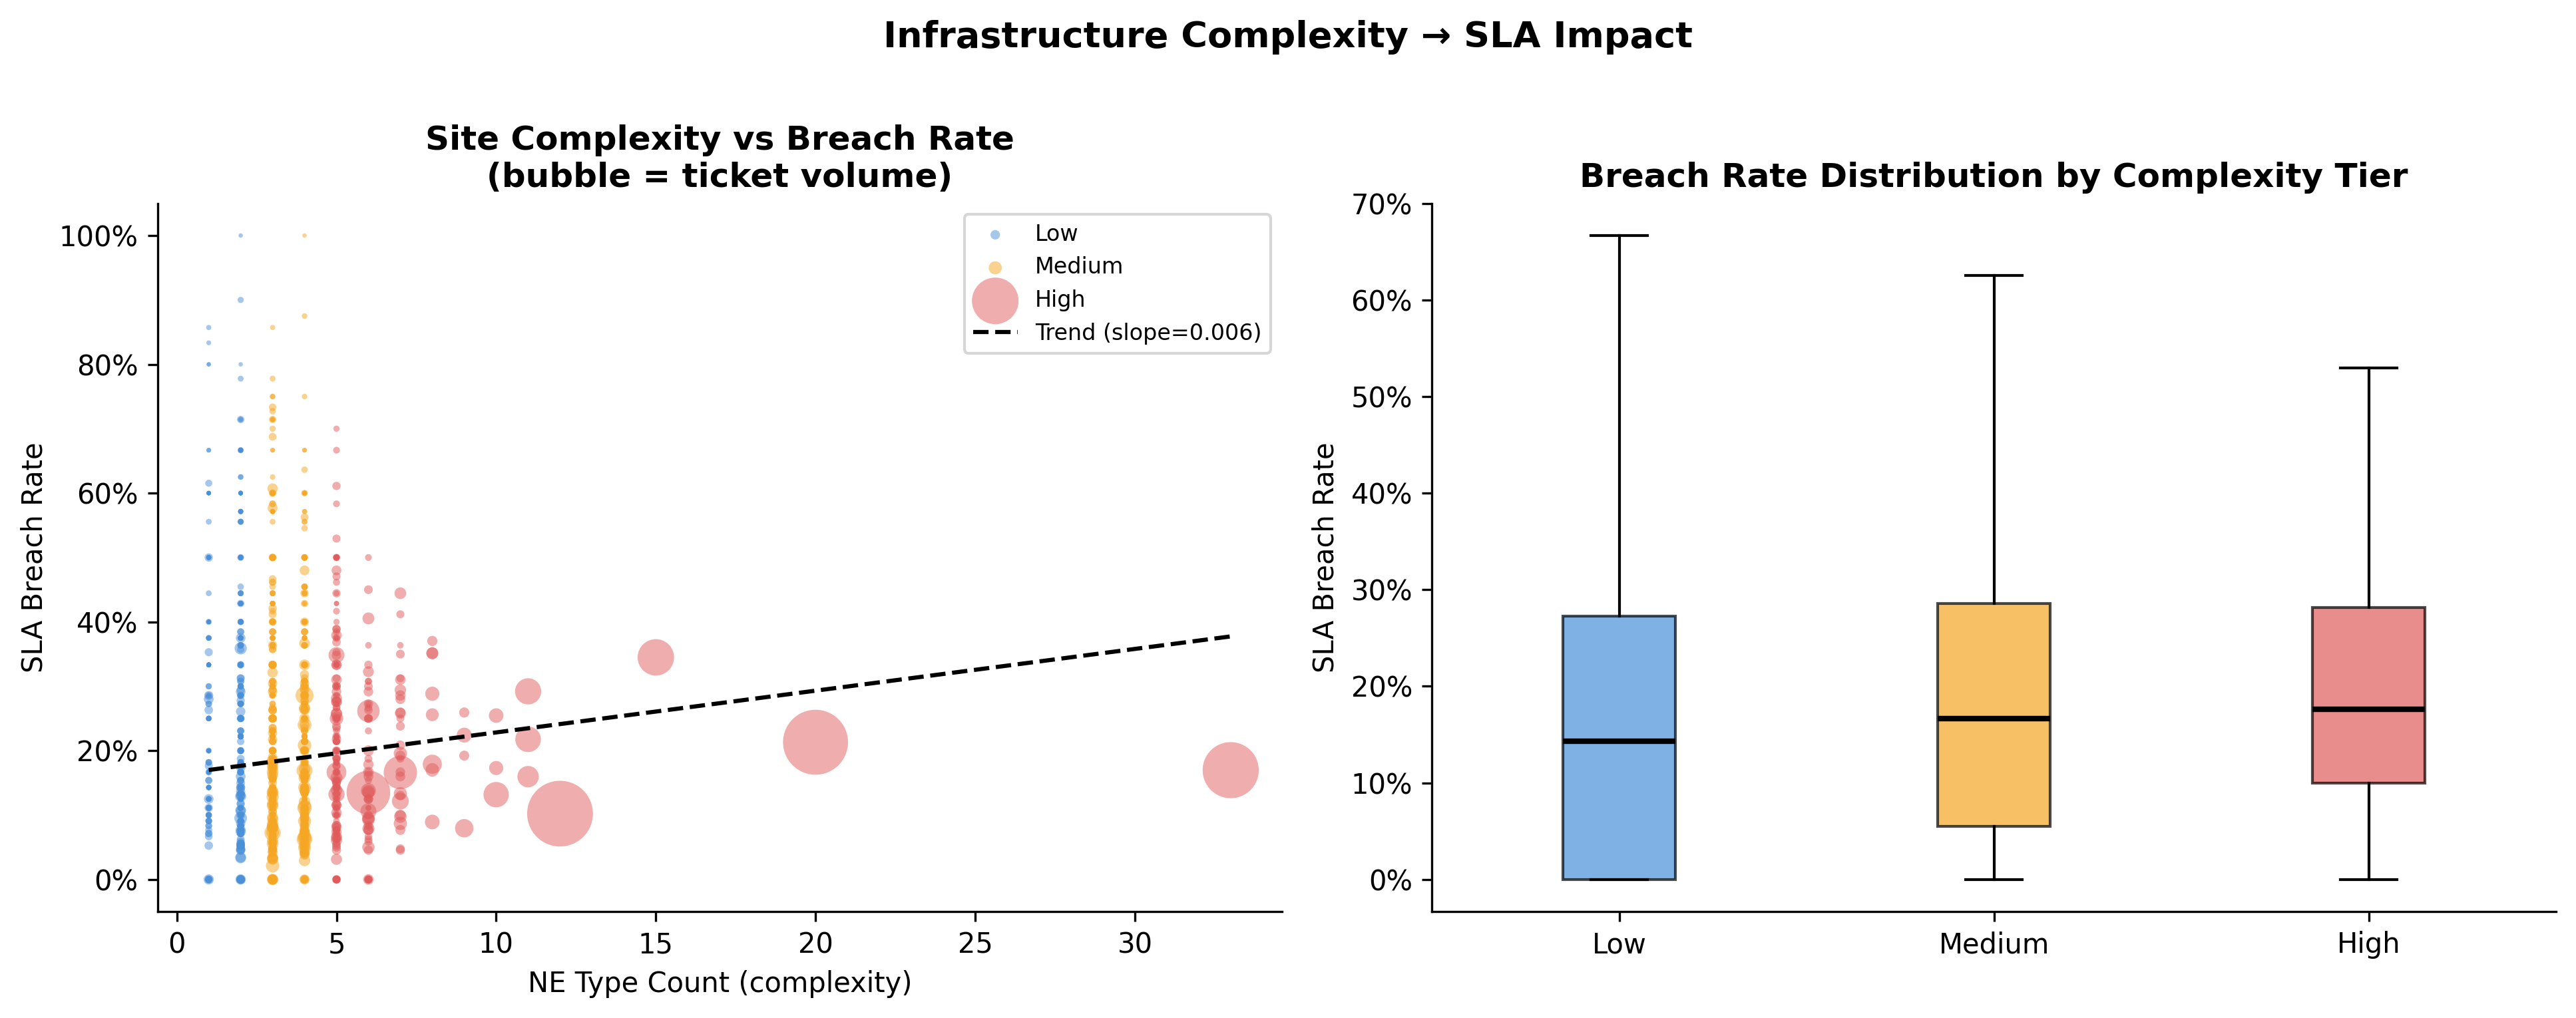

Pearson correlation (NE_Type_Count vs Breach_Rate): r = 0.058


In [12]:
# ── Figure 5: Complexity tier × SLA scatter + regression ──────────────────────
plot_cx = site_cx[site_cx['Ticket_Count'] >= 5].copy()   # min tickets for reliability

tier_colors = {'Low': '#4a90d9', 'Medium': '#f5a623', 'High': '#e05c5c'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter NE_Type_Count vs Breach_Rate
ax = axes[0]
for tier, color in tier_colors.items():
    sub = plot_cx[plot_cx['Complexity_Tier'] == tier]
    ax.scatter(sub['NE_Type_Count'], sub['Breach_Rate'], 
               c=color, alpha=0.5, label=tier, s=sub['Ticket_Count']/2, edgecolors='none')

# Regression line
from numpy.polynomial import polynomial as P
x = plot_cx['NE_Type_Count'].values
y = plot_cx['Breach_Rate'].values
coef = np.polyfit(x, y, 1)
xfit = np.linspace(x.min(), x.max(), 100)
ax.plot(xfit, np.polyval(coef, xfit), 'k--', lw=1.5, label=f'Trend (slope={coef[0]:.3f})')

ax.set_xlabel('NE Type Count (complexity)')
ax.set_ylabel('SLA Breach Rate')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Site Complexity vs Breach Rate\n(bubble = ticket volume)', fontweight='bold')
ax.legend(fontsize=8)

# Right: box plot breach rate by tier
ax2 = axes[1]
tier_order = ['Low', 'Medium', 'High']
data_by_tier = [plot_cx[plot_cx['Complexity_Tier'] == t]['Breach_Rate'].values for t in tier_order]
bp = ax2.boxplot(data_by_tier, tick_labels=tier_order, patch_artist=True, showfliers=False,
                  medianprops={'color':'black','linewidth':2})
for patch, tier in zip(bp['boxes'], tier_order):
    patch.set_facecolor(tier_colors[tier])
    patch.set_alpha(0.7)

ax2.set_ylabel('SLA Breach Rate')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_title('Breach Rate Distribution by Complexity Tier', fontweight='bold')

plt.suptitle('Infrastructure Complexity → SLA Impact', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/19_complexity_vs_sla.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

corr = np.corrcoef(plot_cx['NE_Type_Count'], plot_cx['Breach_Rate'])[0, 1]
print(f"Pearson correlation (NE_Type_Count vs Breach_Rate): r = {corr:.3f}")

## 6. Zone Infrastructure Summary

In [13]:
zone_sum = zone_infra_summary(df)

print("Zone infrastructure summary:")
display(zone_sum[['ZONE','Total_Sites','High_Complexity_Sites','High_Complexity_Share',
                  'NE_Type_Diversity','Avg_MTTR','SLA_Rate','Breach_Rate',
                  'Top_Stress_NE_Type','Repeat_Failure_Combos']]
        .style.format({
            'High_Complexity_Share': '{:.1%}',
            'Avg_MTTR': '{:.1f}h',
            'SLA_Rate': '{:.1%}',
            'Breach_Rate': '{:.1%}',
        })
        .background_gradient(subset='Breach_Rate', cmap='YlOrRd')
)
zone_sum.to_csv('output/infra_zone_summary.csv', index=False)

Zone infrastructure summary:


,ZONE,Total_Sites,High_Complexity_Sites,High_Complexity_Share,NE_Type_Diversity,Avg_MTTR,SLA_Rate,Breach_Rate,Top_Stress_NE_Type,Repeat_Failure_Combos
0,ZONE 5,1059,91,8.6%,30,77.8h,79.6%,20.4%,MSS,998
1,ZONE 3,666,22,3.3%,17,32.3h,80.6%,19.4%,CELL,559
2,ZONE 6,477,47,9.8%,16,70.0h,80.9%,19.1%,SDH MUX,479
3,Unknown,62,4,6.5%,35,150.8h,82.6%,17.4%,HYBRID_A,54
4,ZONE 1,456,25,5.5%,25,62.6h,83.1%,16.9%,ROUTER,502
5,ZONE 2,1043,46,4.4%,25,51.0h,83.9%,16.1%,MSS,870
6,ZONE 4,1040,74,7.1%,25,47.4h,84.5%,15.5%,PE_ROUTER,880


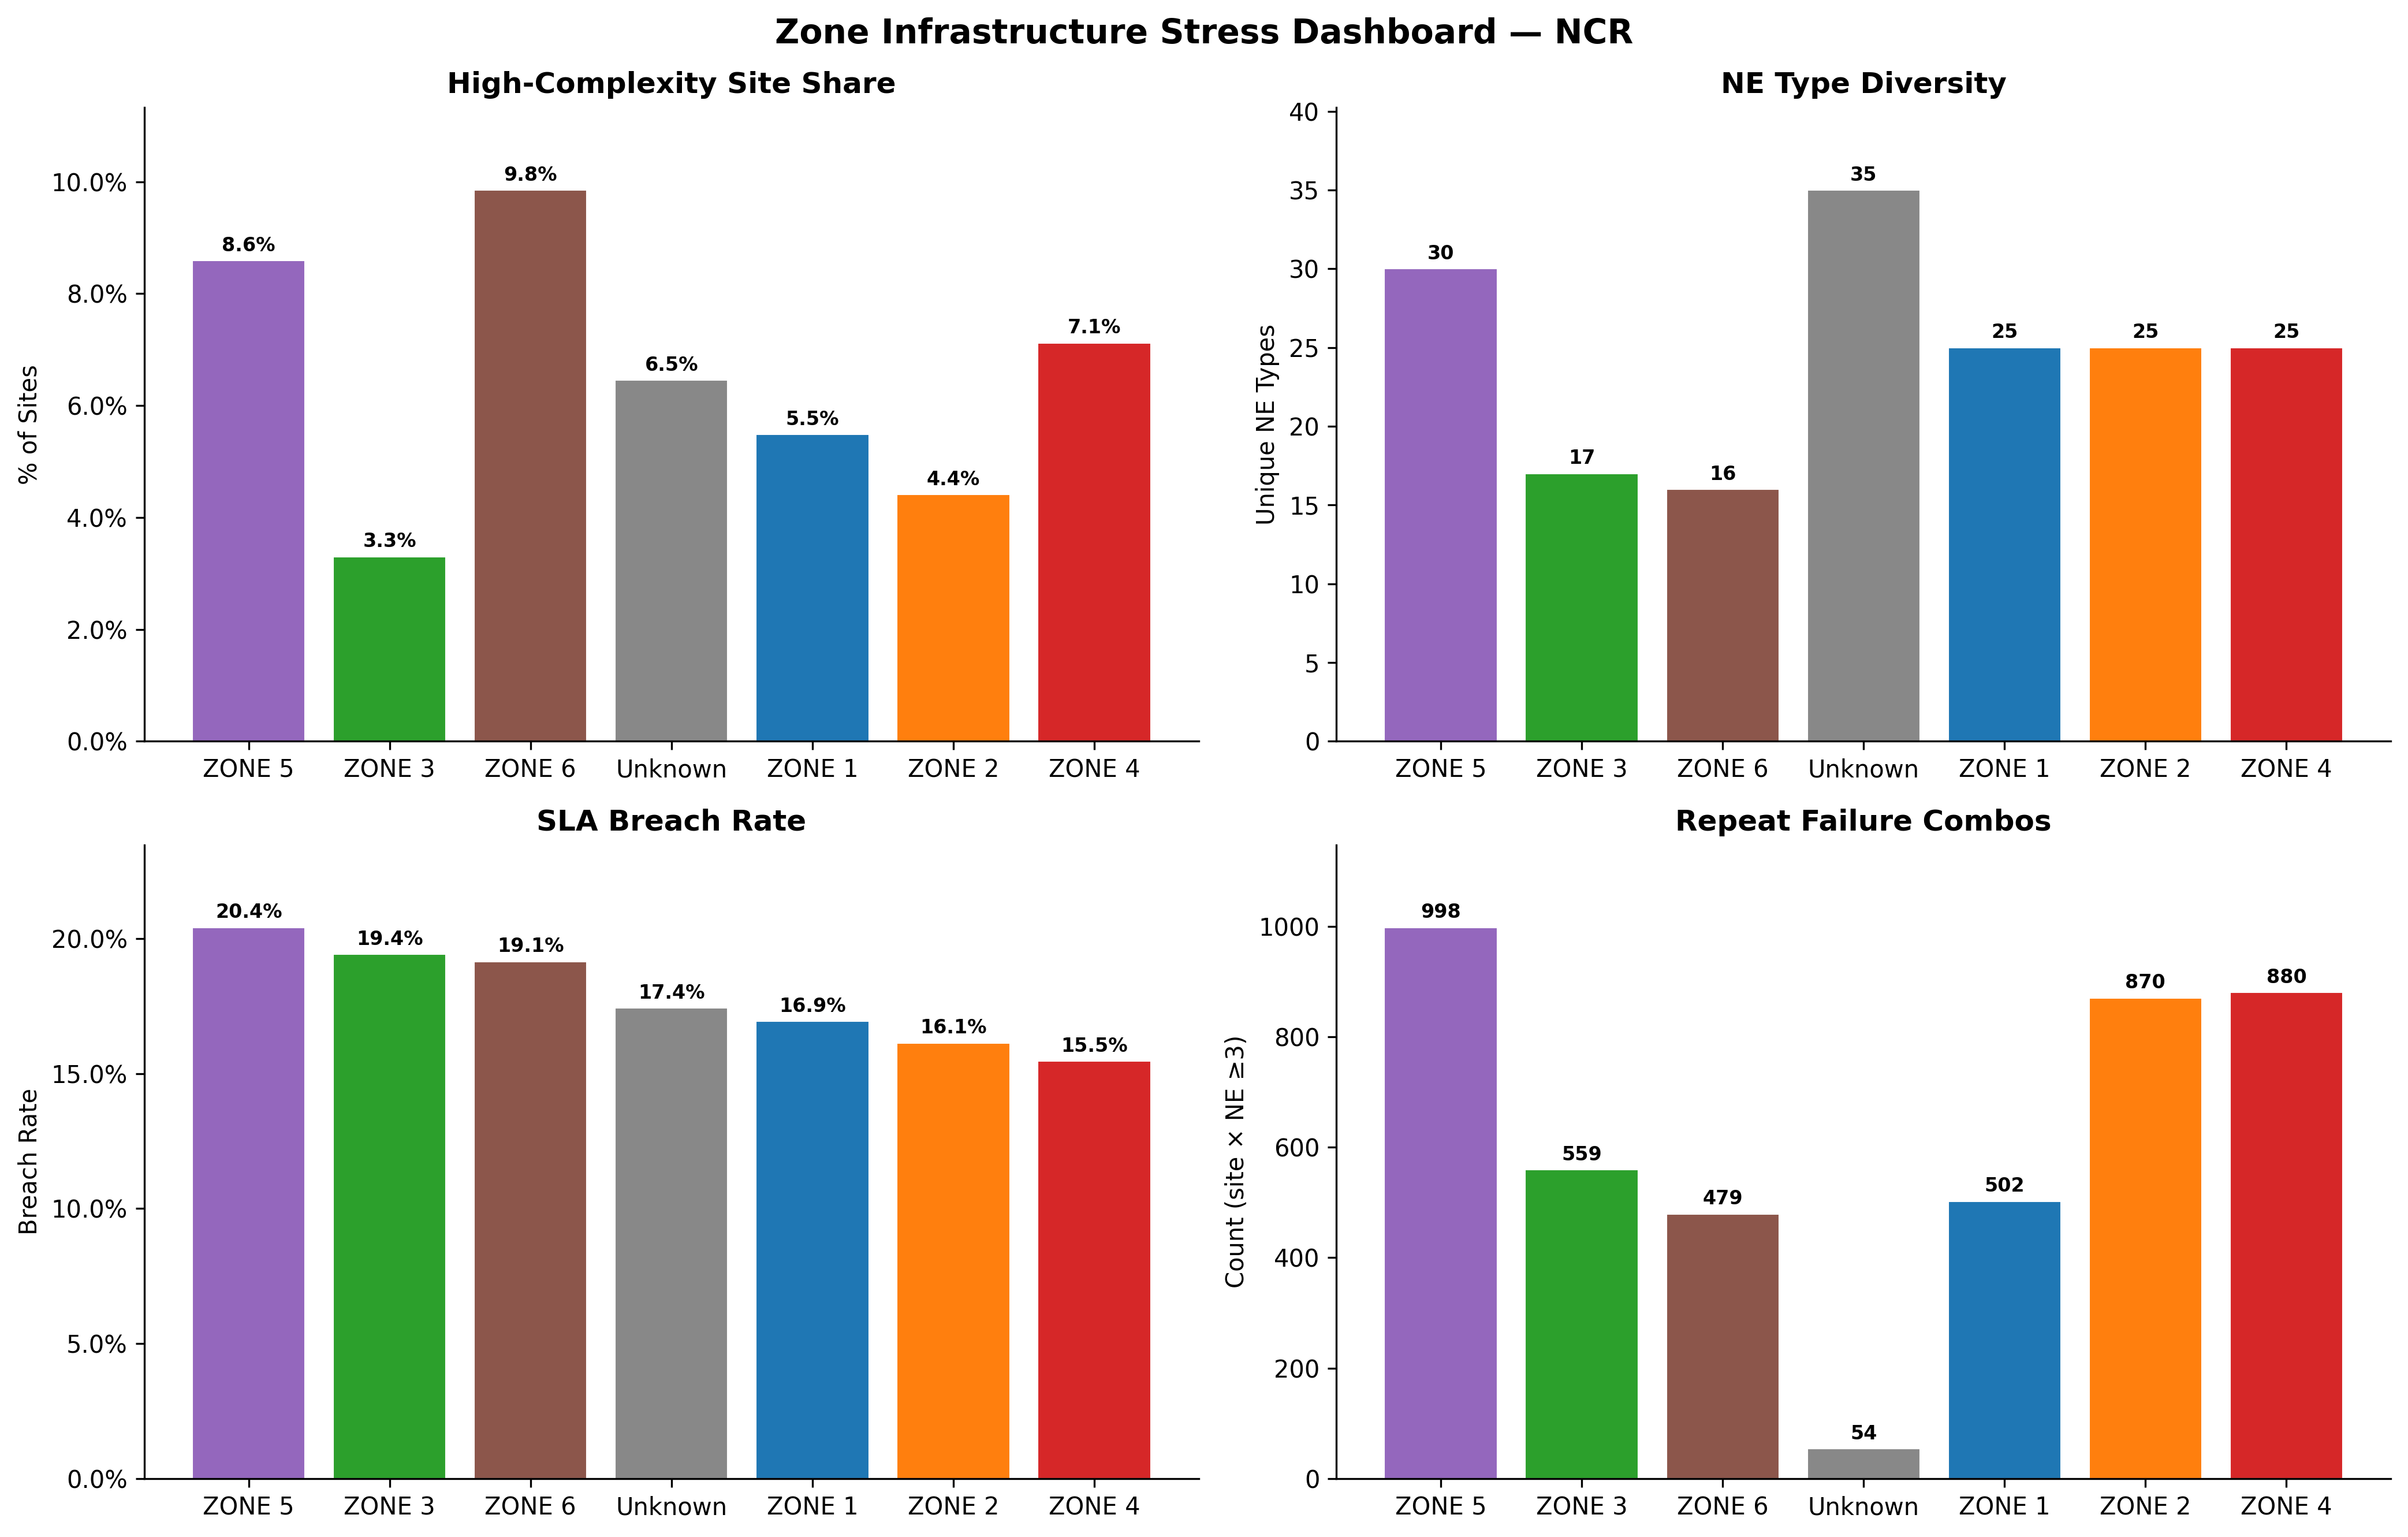

In [14]:
# ── Figure 6: Zone infrastructure dashboard ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
zone_plot = zone_sum.set_index('ZONE')
zones = zone_plot.index.tolist()
colors = [ZONE_PALETTE.get(z, '#888888') for z in zones]

def _bar(ax, col, title, ylabel, fmt=None, pct=False):
    vals = zone_plot[col]
    bars = ax.bar(zones, vals, color=colors, edgecolor='white', linewidth=0.5)
    for bar, v in zip(bars, vals):
        label = f'{v:.1%}' if pct else (f'{v:.1f}' if fmt == 'f' else f'{int(v)}')
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (vals.max() * 0.01),
                label, ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    if pct:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, vals.max() * 1.15)

_bar(axes[0,0], 'High_Complexity_Share', 'High-Complexity Site Share', '% of Sites', pct=True)
_bar(axes[0,1], 'NE_Type_Diversity',     'NE Type Diversity', 'Unique NE Types')
_bar(axes[1,0], 'Breach_Rate',           'SLA Breach Rate', 'Breach Rate', pct=True)
_bar(axes[1,1], 'Repeat_Failure_Combos', 'Repeat Failure Combos', 'Count (site × NE ≥3)')

plt.suptitle('Zone Infrastructure Stress Dashboard — NCR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/19_zone_infra_dashboard.png', dpi=DEFAULT_DPI, bbox_inches='tight')
plt.show()

## 7. Key Findings

Run the cell below to print a concise findings summary derived from the live data.

In [15]:
top_stress_ne = ne_stress.iloc[0]
total_repeat_tickets = repeat['Repeat_Ticket_Count'].sum()
repeat_share = total_repeat_tickets / len(df)
high_cx = site_cx[site_cx['Complexity_Tier'] == 'High']
high_breach_zone = zone_sum.iloc[0]['ZONE']

print("="*70)
print("  PROJECT 6 — NB19 KEY FINDINGS")
print("="*70)
print(f"  Highest-stress NE type : {top_stress_ne['NEType']} "
      f"(stress index {top_stress_ne['Stress_Index']:.3f}, "
      f"breach {top_stress_ne['Breach_Rate']:.1%}, MTTR {top_stress_ne['Avg_MTTR']:.0f}h)")
print(f"  Repeat failure exposure : {total_repeat_tickets:,} tickets ({repeat_share:.1%} of NCR) "
      f"across {len(repeat):,} site×NE combos")
print(f"  High-complexity sites   : {len(high_cx):,} sites (≥5 NE types)")
print(f"    → Avg breach rate     : {high_cx['Breach_Rate'].mean():.1%} "
      f"vs {site_cx[site_cx['Complexity_Tier']=='Low']['Breach_Rate'].mean():.1%} for Low")
print(f"  Most stressed zone      : {high_breach_zone} "
      f"(breach {zone_sum.iloc[0]['Breach_Rate']:.1%})")
print(f"  Core/IP stress flag     : {ne_stress[ne_stress['High_Impact']]['Ticket_Count'].sum():,} tickets "
      f"across {ne_stress['High_Impact'].sum()} high-impact NE types")
print("="*70)

  PROJECT 6 — NB19 KEY FINDINGS
  Highest-stress NE type : vCGW (stress index 13.948, breach 100.0%, MTTR 3028h)
  Repeat failure exposure : 29,419 tickets (76.8% of NCR) across 4,342 site×NE combos
  High-complexity sites   : 309 sites (≥5 NE types)
    → Avg breach rate     : 19.9% vs 18.1% for Low
  Most stressed zone      : ZONE 5 (breach 20.4%)
  Core/IP stress flag     : 4,093 tickets across 17 high-impact NE types
